In [10]:
using Pkg
Pkg.activate("..")   # activate project environment

using Plots
using LaTeXStrings

using NPZ # for numpy-compatible file reading and writing

using Revise # automatically sync src updates
using SkyrmionTunneling
const ST = SkyrmionTunneling # alias for easier coding

  Activating project at `~/Documents/GitHub/skyrmion-tunnelling`


SkyrmionTunneling

# Approaching the continuum

In [157]:
string(3)

"3"

In [173]:
lengthscale = []
skyrmion = []
size_list = []
for i = 200:25:400
    l0 = i / 100
    filename = "../data/k26b40/l"*string(i)*".npy"
    n = npzread(filename)

    push!(lengthscale, l0)
    push!(skyrmion, n)
end

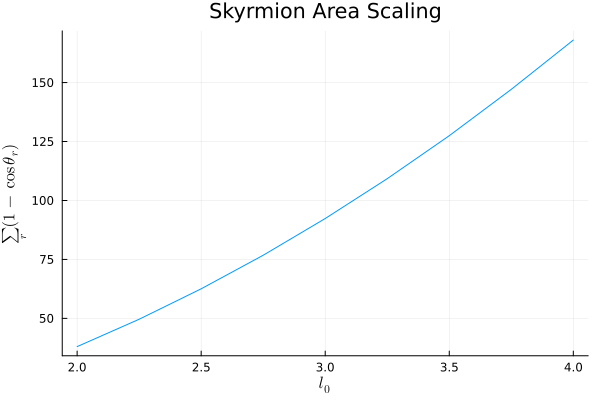

In [233]:
plot(lengthscale, [ST.skyrmion_area.(skyrmion)],
xlabel=L"l_0", ylabel=L"\sum_r (1-\cos \theta_r)", legend=false, title="Skyrmion Area Scaling")

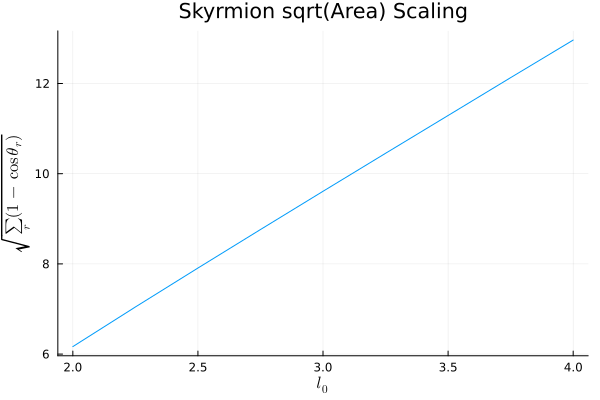

In [232]:
plot(lengthscale, [sqrt(skyrmion_area(n)) for n in skyrmion],
xlabel=L"l_0", ylabel=L"\sqrt{\sum_r (1-\cos \theta_r)}", legend=false, title="Skyrmion sqrt(Area) Scaling")

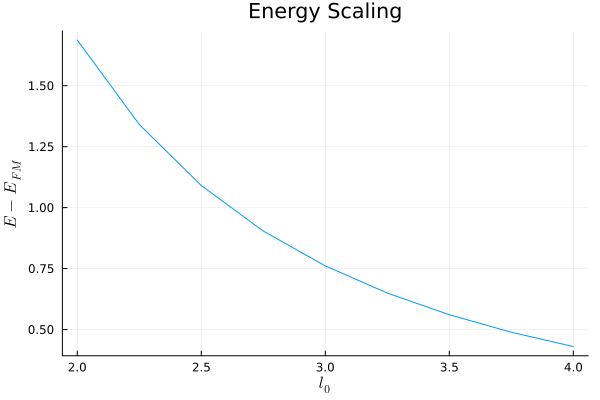

In [ ]:
plot(lengthscale, [H(skyrmion[i], microscopic_system(lengthscale=lengthscale[i], b=2.6, k=4.0, n_sites=50)) for i=1:length(lengthscale)], 
xlabel=L"l_0", ylabel=L"E-E_{FM}", legend=false, title="Energy Scaling")

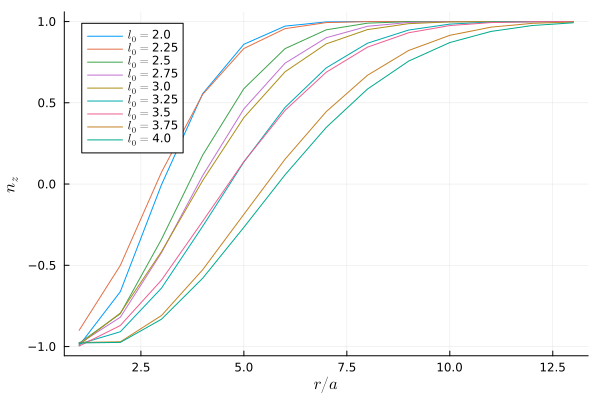

In [202]:
P = plot()
for i=1:length(lengthscale)
    plot!(P, skyrmion[i][3,26,26:1:38], label=L"l_0 = "*string(lengthscale[i]), xlabel=L"r/a", ylabel=L"n_z")
end
display(P)


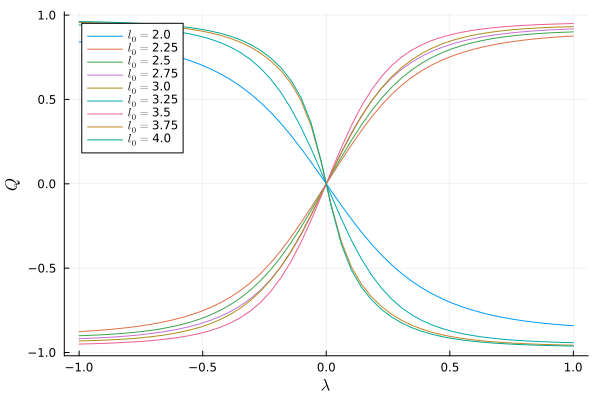

In [213]:
P = plot()
for i=1:length(lengthscale)
    system = microscopic_system(lengthscale=lengthscale[i], k=2.6, b=4.0, n_sites=50)
    coord = LambdaCoordinate(ST.w_project(skyrmion[i]))
    @unpack_system(system)
    lambda_vals = LinRange(-1,1,50)
    plot!(lambda_vals, [topological_charge(ST.n_collective(lambda, lattice, coord), lattice)[1] for lambda in lambda_vals],
    label=L"l_0 = "*string(lengthscale[i]), xlabel=L"\lambda", ylabel=L"Q")
end
display(P)

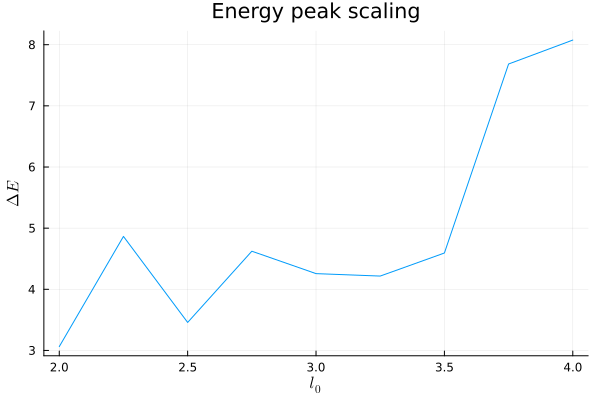

In [222]:
P = plot()
min_energy = []
max_energy = []
for i=1:length(lengthscale)
    system = microscopic_system(lengthscale=lengthscale[i], k=2.6, b=4.0, n_sites=50)
    coord = LambdaCoordinate(ST.w_project(skyrmion[i]))
    @unpack_system(system)
    lambda_vals = LinRange(-1,1,100)
    energies = [H(ST.n_collective(lambda, lattice, coord), system) for lambda in lambda_vals]
    push!(min_energy, minimum(energies))
    push!(max_energy, maximum(energies))
end
plot(lengthscale, max_energy-min_energy, label=false, xlabel=L"l_0", ylabel=L"\Delta E", title="Energy peak scaling")

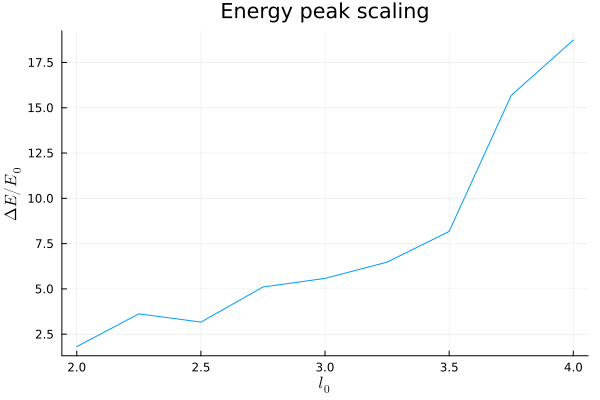

In [223]:
plot(lengthscale, (max_energy-min_energy) ./min_energy, label=false, xlabel=L"l_0", ylabel=L"\Delta E/E_0", title="Energy peak scaling")

sizes = [50]
remainders = Bool[0]
l initial = 1.875
SquareLattice(25, 25)
PeriodicBoundary()
Hamiltonian parameters:
J1 = 1.0	J2 = -0.262	J3 = -0.128
K = 0.014
Bz_avg = 0.021	B_uniform = true



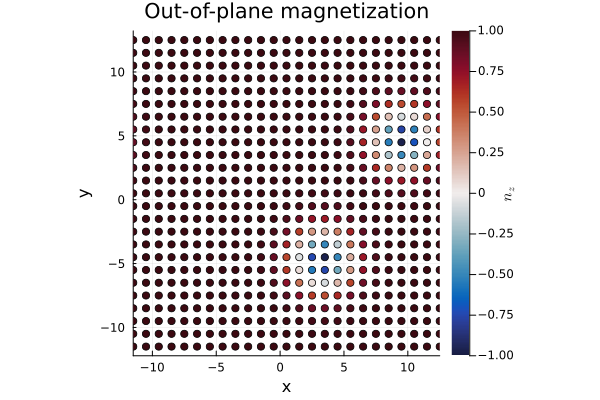






lengthscale = 3.75
SquareLattice(50, 50)
PeriodicBoundary()
Hamiltonian parameters:
J1 = 1.0	J2 = -0.253	J3 = -0.126
K = 0.001
Bz_avg = 0.001	B_uniform = true



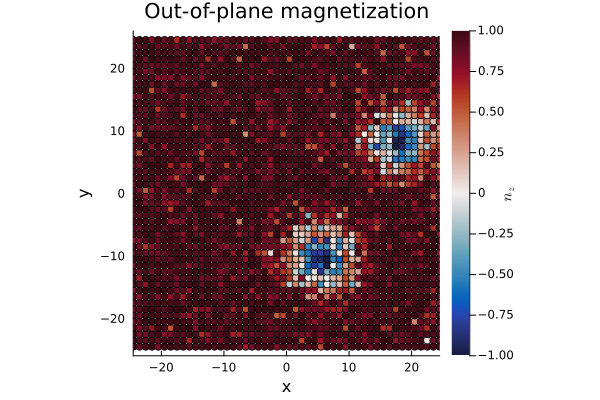

Launching LLG relaxation for


Progress:   2%|▉                                        |  ETA: 0:00:05

SquareLattice(50, 50)
PeriodicBoundary()
Hamiltonian parameters:
J1 = 1.0	J2 = -0.253	J3 = -0.126
K = 0.001
Bz_avg = 0.001	B_uniform = true



Progress: 100%|█████████████████████████████████████████| Time: 0:00:04


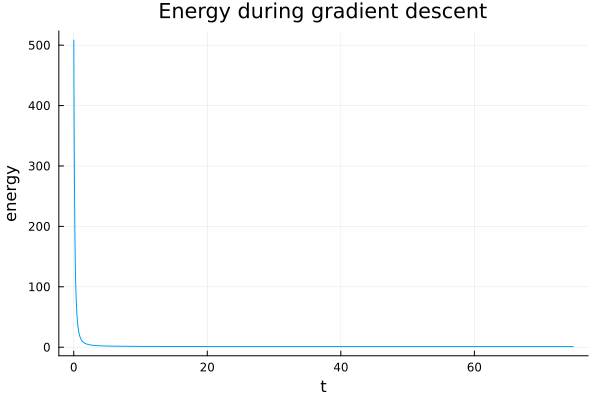

t_max = 74.80014273873292


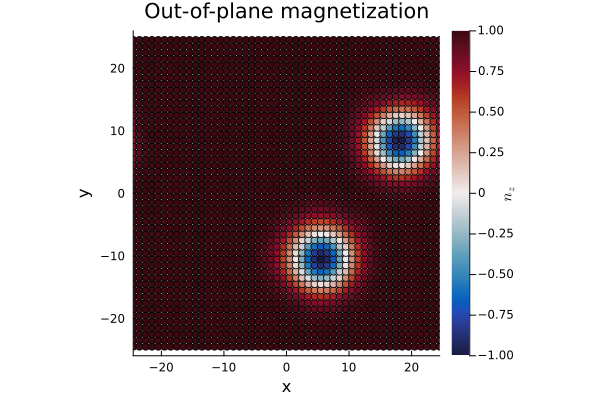

3×50×50 Array{Float64, 3}:
[:, :, 1] =
 -0.0263707  -0.0216025  -0.0177811  …  -0.0268369  -0.0297981  -0.0293452
 -0.118259   -0.113213   -0.104435      -0.109342   -0.117937   -0.120277
  0.992633    0.993336    0.994373       0.993642    0.992574    0.992307

[:, :, 2] =
 -0.0219182  -0.0166207  -0.0123974  …  -0.0329092  -0.0308602  -0.0272132
 -0.0775123  -0.0739168  -0.0693019     -0.079128   -0.0819839  -0.0804443
  0.99675     0.997126    0.997519       0.996321    0.996156    0.996388

[:, :, 3] =
 -0.0179539  -0.0101798  -0.00465094  …  -0.0402907  -0.0337476  -0.026034
 -0.0358602  -0.034432   -0.0339434      -0.0469031  -0.044173   -0.0396269
  0.999196    0.999355    0.999413        0.998087    0.998454    0.998875

;;; … 

[:, :, 48] =
 -0.0508587  -0.0398862  -0.0263688  …  -0.042353  -0.0538881  -0.0566839
 -0.17636    -0.166839   -0.149436      -0.147084  -0.167823   -0.177029
  0.983011    0.985177    0.98842        0.988217   0.984343    0.982572

[:, :, 49] =
 -0.04

In [219]:
system = microscopic_system(lengthscale=3.75, k=2.6, b=4.0, n_sites=50)
n = multiscale_sample(lengthscale=3.75, k=2.6, b=4.0, n_sites=50)

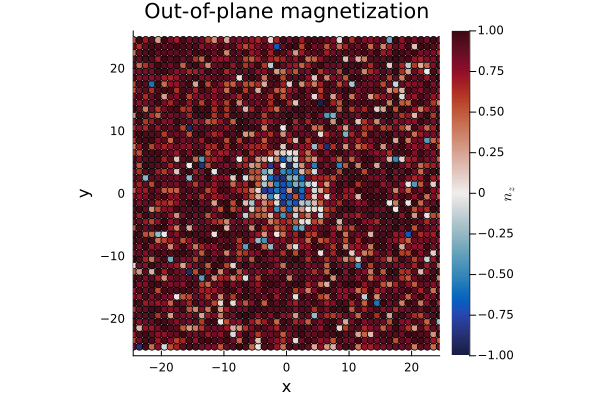

In [150]:
@unpack_system(system)
centre_skyrmion!(n,system)
ST.perturb!(n, amp=0.5)
show_nz(n,lattice)

Progress:   0%|                                         |  ETA: 0:02:30

Launching LLG relaxation for
SquareLattice(50, 50)
PeriodicBoundary()
Hamiltonian parameters:
J1 = 1.0	J2 = -0.253	J3 = -0.126
K = 0.001
Bz_avg = 0.001	B_uniform = true



Progress: 100%|█████████████████████████████████████████| Time: 0:01:17


could not find an improving step; stopped early


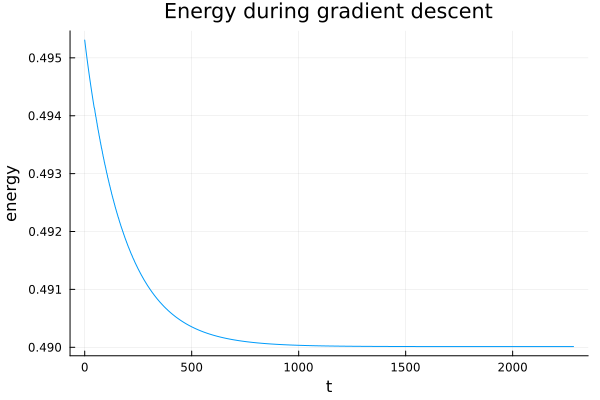

t_max = 2284.499954335108


true

In [164]:
relax!(n, system, graph=true, N_steps=10000)

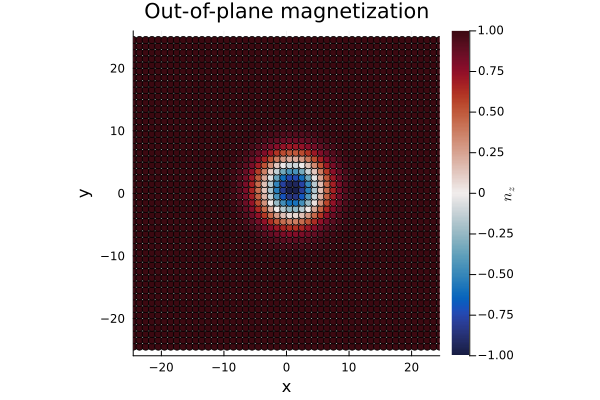

In [165]:
#centre_skyrmion!(n,system)
show_nz(n,lattice)

In [169]:
#npzwrite("../data/k26b40/l375.npy", n)